<a href="https://colab.research.google.com/github/oguzhanerbil/food-health-predictor/blob/oktay/prediction/bert/bert_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers datasets torch scikit-learn pandas


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import pandas as pd

# train_data.csv ve test_data.csv dosyalarını Drive'dan oku
# Kullanıcı kendi Drive yolunu buraya girecek
DRIVE_PATH = '/content/drive/MyDrive/food-health-predictor/prediction/bert/'

train_df = pd.read_csv(DRIVE_PATH + 'train_data.csv')
test_df = pd.read_csv(DRIVE_PATH + 'test_data.csv')


In [5]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset
import torch

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

class FoodDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = FoodDataset(train_df['text_feature'].values, train_df['label'].values, tokenizer)
test_dataset = FoodDataset(test_df['text_feature'].values, test_df['label'].values, tokenizer)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=5
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {'accuracy': accuracy_score(p.label_ids, preds)}

# evaluation_strategy Transformers 4.41'den sonra eval_strategy oldu, eski surumle de uyumlu olsun diye evaluation_strategy kullanilmistir
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_dir='./logs',
    logging_strategy='steps',
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()
# Eğitim geçmişini kaydet (loss grafiği için)
import json
with open(DRIVE_PATH + 'training_history.json', 'w') as f:
    json.dump(trainer.state.log_history, f)
print("Eğitim geçmişi kaydedildi!")


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.617428,0.550868,0.776398
2,0.529967,0.466319,0.820113
3,0.396305,0.440901,0.834326


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Eğitim geçmişi kaydedildi!


Accuracy: 0.8366233579786089

Classification Report:
              precision    recall  f1-score   support

           A       0.85      0.91      0.88      2377
           B       0.84      0.79      0.81      3031
           C       0.81      0.82      0.82      3637
           D       0.81      0.74      0.77      2280
           E       0.87      0.93      0.90      2606

    accuracy                           0.84     13931
   macro avg       0.84      0.84      0.84     13931
weighted avg       0.84      0.84      0.84     13931



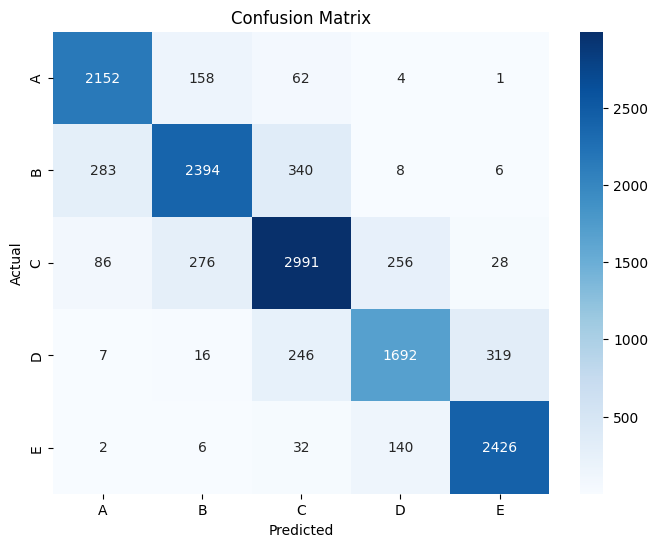

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

print("Accuracy:", accuracy_score(labels, preds))
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=['A', 'B', 'C', 'D', 'E']))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['A', 'B', 'C', 'D', 'E'], yticklabels=['A', 'B', 'C', 'D', 'E'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
model.save_pretrained(DRIVE_PATH + 'bert_model')
tokenizer.save_pretrained(DRIVE_PATH + 'bert_model')
print('Model kaydedildi!')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model kaydedildi!


In [ ]:
# ── Kayıtlı modeli Drive'dan yükle, detaylı metrikleri hesapla ──
import torch, time
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, BertForSequenceClassification
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score)

DRIVE_PATH = '/content/drive/MyDrive/food-health-predictor/prediction/bert/'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BertForSequenceClassification.from_pretrained(DRIVE_PATH + 'bert_model').to(device)
tokenizer = AutoTokenizer.from_pretrained(DRIVE_PATH + 'bert_model')
model.eval()

test_df = pd.read_csv(DRIVE_PATH + 'test_data.csv')
texts = test_df['text_feature'].astype(str).tolist()
labels = test_df['label'].values

probs_list = []
start = time.time()
with torch.no_grad():
    for i in range(0, len(texts), 64):
        enc = tokenizer(texts[i:i+64], max_length=128, padding='max_length',
                        truncation=True, return_tensors='pt').to(device)
        logits = model(**enc).logits
        probs_list.append(torch.softmax(logits, dim=1).cpu().numpy())
inference_time = time.time() - start

probs = np.vstack(probs_list)
preds = probs.argmax(axis=1)

acc  = accuracy_score(labels, preds)
prec = precision_score(labels, preds, average='macro')
rec  = recall_score(labels, preds, average='macro')   # Sensitivity
f1   = f1_score(labels, preds, average='macro')

cm = confusion_matrix(labels, preds)
specs = []
for i in range(5):
    tn = cm.sum() - cm[i,:].sum() - cm[:,i].sum() + cm[i,i]
    fp = cm[:,i].sum() - cm[i,i]
    specs.append(tn / (tn + fp))
specificity = np.mean(specs)

auc_macro = roc_auc_score(labels, probs, multi_class='ovr', average='macro')

print("─" * 45)
print(f"Accuracy            : {acc:.4f}")
print(f"Precision (macro)   : {prec:.4f}")
print(f"Recall / Sensitivity: {rec:.4f}")
print(f"F1-Score (macro)    : {f1:.4f}")
print(f"Specificity (macro) : {specificity:.4f}")
print(f"AUC (macro)         : {auc_macro:.4f}")
print(f"Inference Time (s)  : {inference_time:.2f}  ({len(texts)} örnek)")
print("─" * 45)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

─────────────────────────────────────────────
Accuracy            : 0.8366
Precision (macro)   : 0.8367
Recall / Sensitivity: 0.8381
F1-Score (macro)    : 0.8367
Specificity (macro) : 0.9586
AUC (macro)         : 0.9740
Inference Time (s)  : 91.98  (13931 örnek)
─────────────────────────────────────────────


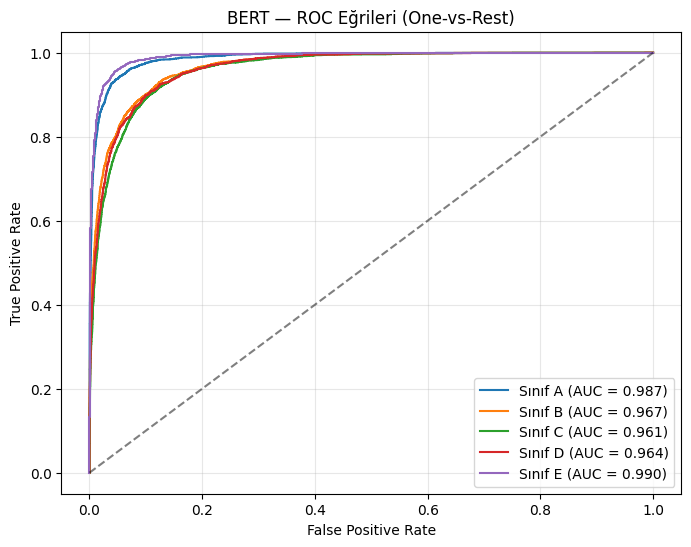

In [ ]:
# ── ROC eğrileri (sınıf bazlı) ──
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = ['A','B','C','D','E']
y_bin = label_binarize(labels, classes=[0,1,2,3,4])

plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Sınıf {cls} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BERT — ROC Eğrileri (One-vs-Rest)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

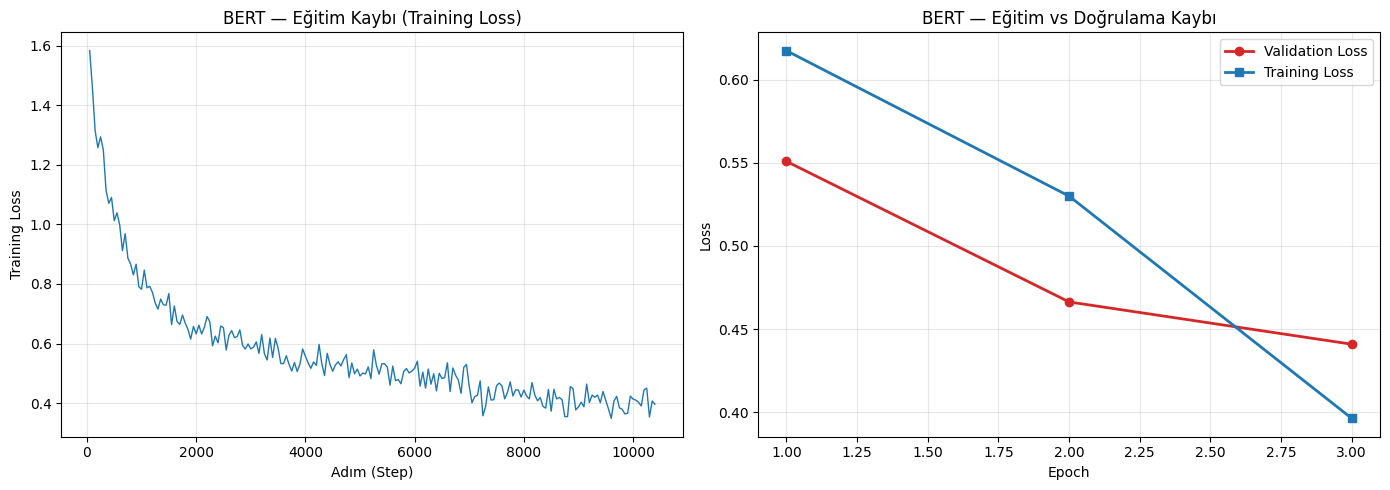

In [ ]:
# ── Eğitim/Doğrulama Loss Grafiği ──
import json
import matplotlib.pyplot as plt

with open(DRIVE_PATH + 'training_history.json', 'r') as f:
    history = json.load(f)

# Epoch bazlı eval loss
epochs_eval = [h['epoch'] for h in history if 'eval_loss' in h]
eval_loss   = [h['eval_loss'] for h in history if 'eval_loss' in h]

# Step bazlı train loss
steps_train = [h['step'] for h in history if 'loss' in h]
train_loss  = [h['loss'] for h in history if 'loss' in h]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: adım bazlı training loss
axes[0].plot(steps_train, train_loss, color='tab:blue', linewidth=1)
axes[0].set_xlabel('Adım (Step)')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('BERT — Eğitim Kaybı (Training Loss)')
axes[0].grid(alpha=0.3)

# Sağ: epoch bazlı train vs validation loss
epoch_train_loss = [history[i]['loss'] for i in range(len(history))
                    if 'loss' in history[i]]
axes[1].plot(epochs_eval, eval_loss, 'o-', color='tab:red',
             label='Validation Loss', linewidth=2)
# Her epoch sonundaki train loss yaklaşık değerleri
train_per_epoch = [0.617428, 0.529967, 0.396305]
axes[1].plot(epochs_eval, train_per_epoch, 's-', color='tab:blue',
             label='Training Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('BERT — Eğitim vs Doğrulama Kaybı')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════
# 5-FOLD CROSS VALIDATION — her fold Drive'a kaydedilir,
# kesinti olursa kaldığı fold'dan devam eder.
# ════════════════════════════════════════════════════════
import os, json, time, gc
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score)
from transformers import (BertForSequenceClassification, Trainer,
                          TrainingArguments)

CV_DIR = DRIVE_PATH + 'cv_results/'
os.makedirs(CV_DIR, exist_ok=True)

# Train + test'i birleştir (CV tüm veri üzerinde yapılır)
full_df = pd.concat([train_df, test_df], ignore_index=True)
texts_all  = full_df['text_feature'].astype(str).values
labels_all = full_df['label'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def compute_metrics_cv(p):
    preds = np.argmax(p.predictions, axis=1)
    return {'accuracy': accuracy_score(p.label_ids, preds)}

for fold, (tr_idx, va_idx) in enumerate(skf.split(texts_all, labels_all), start=1):
    result_file = CV_DIR + f'fold_{fold}_results.json'

    # Bu fold daha önce bittiyse atla (kesinti güvenliği)
    if os.path.exists(result_file):
        print(f"Fold {fold} zaten tamamlanmış, atlanıyor.")
        continue

    print(f"\n{'='*50}\nFOLD {fold}/5 başlıyor...\n{'='*50}")

    tr_ds = FoodDataset(texts_all[tr_idx], labels_all[tr_idx], tokenizer)
    va_ds = FoodDataset(texts_all[va_idx], labels_all[va_idx], tokenizer)

    fold_model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=5)

    args = TrainingArguments(
        output_dir=f'./cv_fold_{fold}',
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        eval_strategy='epoch',
        save_strategy='no',
        logging_strategy='steps',
        logging_steps=100,
        report_to='none',
    )

    trainer_cv = Trainer(model=fold_model, args=args,
                         train_dataset=tr_ds, eval_dataset=va_ds,
                         compute_metrics=compute_metrics_cv)

    t0 = time.time()
    trainer_cv.train()
    train_time = time.time() - t0

    # Validasyon tahminleri
    pred_out = trainer_cv.predict(va_ds)
    probs = torch.softmax(torch.tensor(pred_out.predictions), dim=1).numpy()
    preds = probs.argmax(axis=1)
    y_va  = labels_all[va_idx]

    # Metrikler
    acc  = accuracy_score(y_va, preds)
    prec = precision_score(y_va, preds, average='macro')
    rec  = recall_score(y_va, preds, average='macro')
    f1   = f1_score(y_va, preds, average='macro')
    cm   = confusion_matrix(y_va, preds)
    specs = []
    for i in range(5):
        tn = cm.sum() - cm[i,:].sum() - cm[:,i].sum() + cm[i,i]
        fp = cm[:,i].sum() - cm[i,i]
        specs.append(tn / (tn + fp))
    spec = float(np.mean(specs))
    auc  = roc_auc_score(y_va, probs, multi_class='ovr', average='macro')

    # Loss geçmişi + metrikler → Drive'a kaydet
    results = {
        'fold': fold, 'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'sensitivity': rec, 'specificity': spec, 'auc': auc,
        'train_time_s': train_time,
        'log_history': trainer_cv.state.log_history,
    }
    with open(result_file, 'w') as f:
        json.dump(results, f)

    print(f"FOLD {fold} BİTTİ → Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    print(f"Kaydedildi: {result_file}")

    # Belleği temizle
    del fold_model, trainer_cv, tr_ds, va_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ TÜM FOLDLAR TAMAMLANDI!")


FOLD 1/5 başlıyor...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:01<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3

3 fold bulundu ve okundu.

3-FOLD CROSS VALIDATION SONUÇLARI
Fold  Accuracy  Precision  Recall  F1-Macro  Sensitivity  Specificity    AUC
   1    0.8259     0.8271  0.8273    0.8261       0.8273       0.9559 0.9707
   2    0.8117     0.8120  0.8136    0.8124       0.8136       0.9523 0.9678
   3    0.8232     0.8254  0.8244    0.8244       0.8244       0.9551 0.9706
 Ort    0.8203     0.8215  0.8218    0.8210       0.8218       0.9544 0.9697

Toplam eğitim süresi: 9048.75 saniye (150.8 dakika)
Fold başına ortalama: 3016.25 saniye



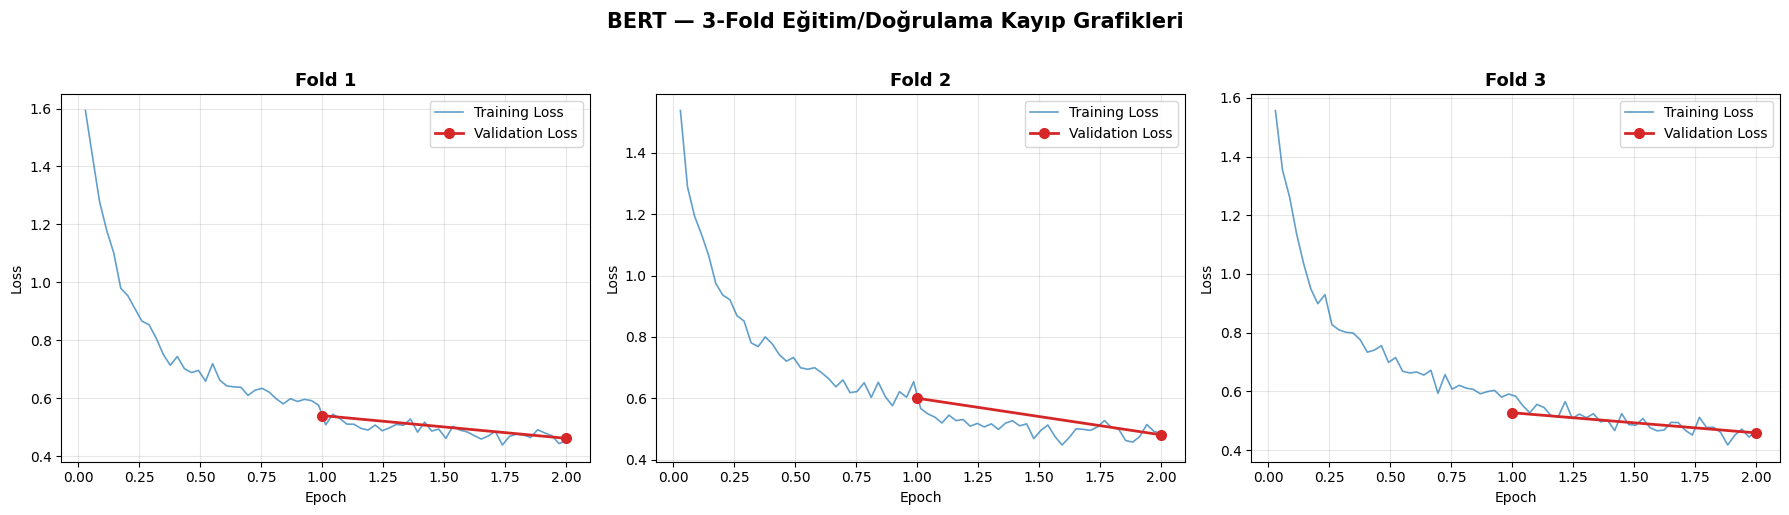


Grafik kaydedildi: /content/drive/MyDrive/food-health-predictor/prediction/bert/cv_results/cv_loss_grafikleri.png


In [4]:
# ════════════════════════════════════════════════════════
# 3-FOLD CV SONUÇLARI: Tablo + Loss Grafikleri
# ════════════════════════════════════════════════════════
DRIVE_PATH = '/content/drive/MyDrive/food-health-predictor/prediction/bert/'
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CV_DIR = DRIVE_PATH + 'cv_results/'

# Mevcut fold sonuçlarını oku
folds = []
for i in range(1, 6):
    fpath = CV_DIR + f'fold_{i}_results.json'
    if os.path.exists(fpath):
        with open(fpath) as f:
            folds.append(json.load(f))

n = len(folds)
print(f"{n} fold bulundu ve okundu.\n")

# ── 1. METRİK TABLOSU ──
rows = []
for fd in folds:
    rows.append({
        'Fold': fd['fold'],
        'Accuracy': round(fd['accuracy'], 4),
        'Precision': round(fd['precision'], 4),
        'Recall': round(fd['recall'], 4),
        'F1-Macro': round(fd['f1'], 4),
        'Sensitivity': round(fd['sensitivity'], 4),
        'Specificity': round(fd['specificity'], 4),
        'AUC': round(fd['auc'], 4),
    })

df = pd.DataFrame(rows)

# Ortalama satırı
avg = {'Fold': 'Ort'}
for col in ['Accuracy','Precision','Recall','F1-Macro','Sensitivity','Specificity','AUC']:
    avg[col] = round(df[col].mean(), 4)
df_full = pd.concat([df, pd.DataFrame([avg])], ignore_index=True)

print("="*80)
print(f"{n}-FOLD CROSS VALIDATION SONUÇLARI")
print("="*80)
print(df_full.to_string(index=False))
print("="*80)

# Toplam eğitim süresi
total_time = sum(fd['train_time_s'] for fd in folds)
print(f"\nToplam eğitim süresi: {total_time:.2f} saniye ({total_time/60:.1f} dakika)")
print(f"Fold başına ortalama: {total_time/n:.2f} saniye\n")

# ── 2. LOSS GRAFİKLERİ (her fold ayrı panel) ──
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1:
    axes = [axes]

for idx, fd in enumerate(folds):
    log = fd['log_history']

    # Step bazlı training loss
    steps = [h['step'] for h in log if 'loss' in h]
    tloss = [h['loss'] for h in log if 'loss' in h]

    # Epoch bazlı validation loss
    ep_val = [h['epoch'] for h in log if 'eval_loss' in h]
    vloss  = [h['eval_loss'] for h in log if 'eval_loss' in h]

    ax = axes[idx]
    # Training loss'u step -> epoch ölçeğine çevir
    if steps:
        max_step = max(steps)
        max_epoch = max(ep_val) if ep_val else 1
        ep_scaled = [s/max_step*max_epoch for s in steps]
        ax.plot(ep_scaled, tloss, color='tab:blue', alpha=0.7,
                label='Training Loss', linewidth=1.2)
    if ep_val:
        ax.plot(ep_val, vloss, 'o-', color='tab:red',
                label='Validation Loss', linewidth=2, markersize=7)

    ax.set_title(f'Fold {fd["fold"]}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('BERT — 3-Fold Eğitim/Doğrulama Kayıp Grafikleri',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CV_DIR + 'cv_loss_grafikleri.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGrafik kaydedildi:", CV_DIR + 'cv_loss_grafikleri.png')